<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4p/blob/main/50_cmdstanpy.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(cmdstanpy-notebook)=
# CmdStanPy

Nel presente capitolo, presenteremo un linguaggio di programmazione probabilistica denominato [Stan](http://mc-stan.org/). Stan consente di estrarre campioni da distribuzioni di probabilità mediante la costruzione di una catena di Markov, la cui distribuzione di equilibrio (o stazionaria) coincide con la distribuzione desiderata. Il nome del linguaggio deriva da uno dei pionieri del metodo Monte Carlo, Stanislaw Ulam. Un'introduzione dettagliata al linguaggio Stan è fornita in {ref}`appendix-cmdstanpy`. in questo capitolo, utilizzeremo Stan per fare inferenza su una proporzione.

## Procedura di Installazione

Il linguaggio di programmazione probabilistica Stan è compatibile con diverse piattaforme e offre varie interfacce (R, Python, Julia). Nel caso presente, useremo `cmdstanpy`, un'interfaccia leggera per Stan pensata per gli utenti di Python.

CmdStanPy è un pacchetto puramente in Python3 che è un wrapper di CmdStan, l'interfaccia a riga di comando per Stan scritta in C++. Pertanto, oltre a Python3, CmdStanPy richiede un toolchain C++ moderno per compilare ed eseguire i modelli Stan.

È possibile scaricare CmdStanPy, CmdStan e il toolchain C++ da conda-forge. Se si utilizza `conda`, è possibile [installare](https://mc-stan.org/cmdstanpy/installation.html) CmdStanPy e i componenti sottostanti di CmdStan dal repository conda-forge tramite il seguente comando:

```bash
conda create -n stan_env -c conda-forge cmdstanpy
```

Questo comando crea un nuovo ambiente conda chiamato `stan_env` e scarica e installa il pacchetto cmdstanpy insieme a CmdStan e al toolchain C++ necessario.

Una volta creato l'ambiente virtuale, è possibile attivarlo mediante il comando:

```bash
conda activate stan_env
```

Successivamente, è possibile installare i pacchetti aggiuntivi necessari con il comando:

```bash
conda install -c conda-forge seaborn arviz watermark -y
```

## Preparazione del Notebook

Una volta creato l'ambiente conda `stan_env`, attiviamo il kernel di Visual Studio Code selezionando questo ambiente virtuale. Possiamo quindi caricare i pacchetti necessari.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import arviz as az
import warnings
from cmdstanpy import cmdstan_path, CmdStanModel

/Users/corrado/opt/anaconda3/envs/stan_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
sns.set_theme(palette="colorblind")

In questo tutorial ripeteremo l'analisi descritta nel capitolo {ref}`mcmc-bayes-inference-notebook`, ovvero considereremo un modello beta-binomiale. I dati sono quelli dell'esempio relativo agli artisti della Generazione X rappresentati al MOMA. Esaminando 100 opere a caso, abbiamo registrato 14 successi su 100 tentativi. Abbiamo deciso di imporre sul parametro $ \theta $ (la probabilità di appartenere alla Generazione X o a generazioni successive) una distribuzione a priori Beta(4, 6).

Il nostro modello è il seguente:

$$
\begin{align*}
\theta &\sim \text{Beta}(4, 6), \\
y &\sim \text{Bin}(n, \theta).
\end{align*}
$$

Il modello deve essere scritto in linguaggio Stan in un file con l'estensione `.stan`. Nel caso presente, tale file è presente nella cartella `stan` ed è chiamato `bernoulli_model.stan`. Possiamo stamparlo nel notebook nel modo seguente:

In [3]:
stan_file = os.path.join('stan', 'bernoulli_model.stan')
with open(stan_file, 'r') as f:
    print(f.read())

data {
  int<lower=0> N;
  array[N] int<lower=0, upper=1> y;
}
parameters {
  real<lower=0, upper=1> theta;
}
model {
  theta ~ beta(4, 6);
  y ~ bernoulli(theta);
}
generated quantities {
    array[N] int<lower=0, upper=1> y_rep; // generated data for posterior predictive checks
    array[N] real log_lik; // log likelihood for each observation

    for (n in 1:N) {
        y_rep[n] = bernoulli_rng(theta); // simulate new data based on posterior of theta
        log_lik[n] = bernoulli_lpmf(y[n] | theta); // calculate log likelihood for each observed data point
    }
}



Per svolgere l'analisi mediante `cmdstanpy` è necessario prima specificare la struttura del modello bayesiano nella notazione Stan e, poi, eseguire il campionamento dalla distribuzione a posteriori. Esaminiamo questi due passaggi per l'esempio presente.

Nella prima fase dell'analisi dobbiamo specificare il modello. Nel codice precedente, il blocco `data` specifica i dati che saranno passati in input a Stan. Nel caso presente, abbiamo `N` che è un numero intero (con valore minimo 0) e `y`. L'array `y` è costituito da N elementi i quali hanno valore minimo 0 e valore massimo 1.

Il blocco `parameters` specifica che il parametro `theta` è un valore reale che può assumere valore minimo 0 e valore massimo 1.

Il blocco `model` specifica la verosimiglianza `y ~ bernoulli(theta);`. Nel caso presente diciamo che ciascuna osservazione di `y` è una variabile casuale di Bernoulli di parametro `theta`. È anche necessario specificare la distribuzione a priori `theta`: `theta ~ beta(4, 6);`. In questo esempio, imponiamo su `theta` una Beta(4, 6).

Utilizzando il seguente [link](https://rok-cesnovar.github.io/stanc3js-demo/autoformat.html) si può ottenere una formattazione automatica del codice e anche, in qualche misura, una correzione della sintassi.

Per utilizzare il modello che abbiamo specificato, prima leggiamo l'indirizzo del file che contiene il codice Stan. Abbiamo già ottenuto questo in precedenza con l'istruzione `stan_file = os.path.join('stan', 'bernoulli_model.stan')`.

Possiamo ora compilare il codice Stan. Questo crea un file eseguibile che, nel caso presente, abbiamo chiamato `model`.

In [4]:
model = CmdStanModel(stan_file=stan_file)
print(model)

22:28:49 - cmdstanpy - INFO - compiling stan file /Users/corrado/_repositories/ds4p/chapter_4/stan/bernoulli_model.stan to exe file /Users/corrado/_repositories/ds4p/chapter_4/stan/bernoulli_model
22:29:28 - cmdstanpy - INFO - compiled model executable: /Users/corrado/_repositories/ds4p/chapter_4/stan/bernoulli_model


CmdStanModel: name=bernoulli_model
	 stan_file=/Users/corrado/_repositories/ds4p/chapter_4/stan/bernoulli_model.stan
	 exe_file=/Users/corrado/_repositories/ds4p/chapter_4/stan/bernoulli_model
	 compiler_options=stanc_options={}, cpp_options={}


I dati devono essere contenuti in un dizionario. Nel caso presente, il dizionario `data` può essere creato nel modo seguente.

In [5]:
y = np.zeros(100, dtype=int)
y[:14] = 1

data = {
    "N" : 100,
    "y" : y
}

print(data)

{'N': 100, 'y': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])}


Possiamo ora eseguire il campionamento MCMC con la seguente chiamata.

In [6]:
fit = model.sample(
    data=data,
    iter_sampling = 4000,
    iter_warmup = 2000,
    seed = 84735,
    chains = 4
)

22:29:36 - cmdstanpy - INFO - CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |████▎     | 00:00 Iteration: 2400 / 6000 [ 40%]  (Sampling)





chain 1 |██████████| 00:00 Sampling completed                       
chain 2 |██████████| 00:00 Sampling completed                       
chain 3 |██████████| 00:00 Sampling completed                       
chain 4 |██████████| 00:00 Sampling completed                       


22:29:37 - cmdstanpy - INFO - CmdStan done processing.


Si noti che `$sample()` è un "metodo" che viene applicato al file eseguibile che abbiamo compilato, al quale è stato assegnato il nome `model`.

Il metodo `$sample()` richiede una serie di argomenti.

-   `data`, ovvero i dati in input contenuti in un dizionario (nel caso presente, `data`).
-   `chains` specifica quante catene di Markov parallele eseguire. Eseguiamo qui quattro catene, quindi otterremo quattro campioni distinti di valori $\theta$.
-   `iter` specifica il numero desiderato di iterazioni o la lunghezza di ciascuna catena di Markov. Per impostazione predefinita, la prima metà di queste iterazioni è costituita da campioni "burn-in" o "warm-up" che verranno ignorati. La seconda metà è conservata e costituisce un campione della distribuzione a posteriori.
-   `iter_warmup` specifica il numero di campioni "warm-up" che vogliamo vengano ignorati.
-   `seed` imposta il numero casuale che viene usato per generare il punto di partenza di ciascuna catena di Markov.

Avendo assunto una distribuzione a priori per il parametro $\theta$, l'algoritmo procede in maniera ciclica, correggendo la distribuzione a priori di $\theta$ condizionandola ai valori già generati. Dopo un certo numero di cicli, necessari per portare l'algoritmo a convergenza, i valori estratti possono essere assunti come campionati dalla distribuzione a posteriori di $\theta$.

Al crescere del numero di passi della catena, la distribuzione di target viene sempre meglio approssimata. All'inizio del campionamento, però, la distribuzione può essere significativamente lontana da quella stazionaria, e ci vuole un certo tempo prima di raggiungere la distribuzione stazionaria di equilibrio, detto, appunto, periodo di *burn-in*. I campioni provenienti da tale parte iniziale della catena vanno tipicamente scartati perché possono non rappresentare accuratamente la distribuzione a posteriori.

Un sommario della distribuzione a posteriori del parametro `theta` si può ottenere con il metodo `summary()`

In [7]:
print(fit.summary())

                   Mean      MCSE    StdDev         5%        50%        95%  \
lp__         -49.520500  0.009097  0.715962 -50.934700 -49.245500 -49.023700   
theta          0.164082  0.000457  0.035006   0.109924   0.161850   0.224372   
y_rep[1]       0.163500  0.002937  0.369833   0.000000   0.000000   1.000000   
y_rep[2]       0.161188  0.002888  0.367715   0.000000   0.000000   1.000000   
y_rep[3]       0.167063  0.002994  0.373043   0.000000   0.000000   1.000000   
...                 ...       ...       ...        ...        ...        ...   
log_lik[96]   -0.180113  0.000551  0.042295  -0.254083  -0.176555  -0.116465   
log_lik[97]   -0.180113  0.000551  0.042295  -0.254083  -0.176555  -0.116465   
log_lik[98]   -0.180113  0.000551  0.042295  -0.254083  -0.176555  -0.116465   
log_lik[99]   -0.180113  0.000551  0.042295  -0.254083  -0.176555  -0.116465   
log_lik[100]  -0.180113  0.000551  0.042295  -0.254083  -0.176555  -0.116465   

                 N_Eff  N_Eff/s    R_ha

In [34]:
print(fit.diagnose())

Processing csv files: /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpniqk6lav/bernoulli_modelkzvi8m0r/bernoulli_model-20240224085517_1.csv, /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpniqk6lav/bernoulli_modelkzvi8m0r/bernoulli_model-20240224085517_2.csv, /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpniqk6lav/bernoulli_modelkzvi8m0r/bernoulli_model-20240224085517_3.csv, /var/folders/cl/wwjrsxdd5tz7y9jr82nd5hrw0000gn/T/tmpniqk6lav/bernoulli_modelkzvi8m0r/bernoulli_model-20240224085517_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all parameters.

Processing complete, no problems detected.



L'oggetto `fit` generato da `cmdstanpy` appartiene alla classe `cmdstanpy.stanfit.mcmc.CmdStanMCMC`. Questo oggetto è funzionalmente equivalente a un oggetto della classe `InferenceData`, permettendo quindi la sua manipolazione tramite le funzioni fornite da ArviZ.

In [8]:
type(fit)

cmdstanpy.stanfit.mcmc.CmdStanMCMC

In [8]:
az.summary(fit, var_names=("theta"), hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.164,0.035,0.1,0.235,0.0,0.0,5810.0,6591.0,1.0


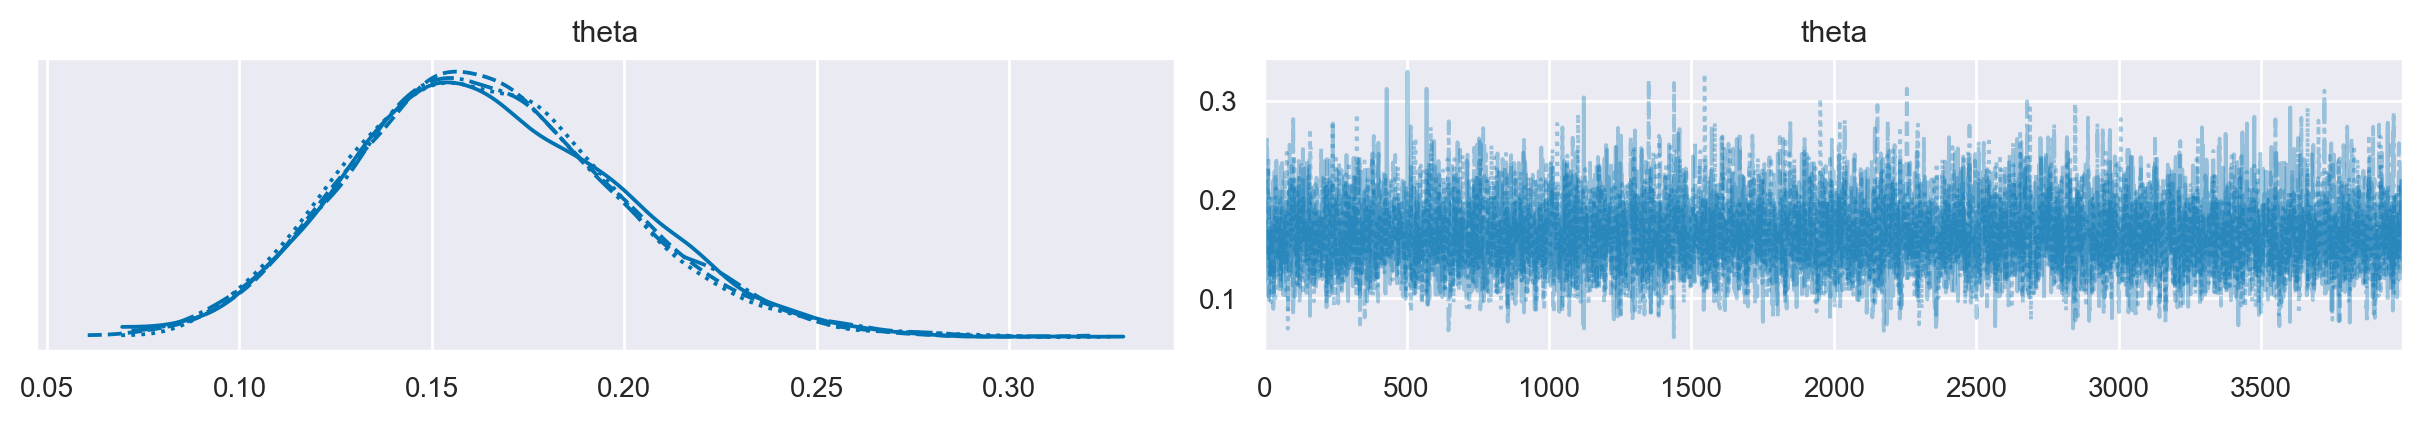

In [9]:
_ = az.plot_trace(fit, var_names=("theta"))

In [10]:
post = az.extract(fit)
post

<xarray.Dataset> Size: 13MB
Dimensions:      (sample: 16000, y_rep_dim_0: 100)
Coordinates:
  * y_rep_dim_0  (y_rep_dim_0) int64 800B 0 1 2 3 4 5 6 ... 93 94 95 96 97 98 99
  * sample       (sample) object 128kB MultiIndex
  * chain        (sample) int64 128kB 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3
  * draw         (sample) int64 128kB 0 1 2 3 4 5 ... 3995 3996 3997 3998 3999
Data variables:
    theta        (sample) float64 128kB 0.1469 0.1473 0.1505 ... 0.1629 0.155
    y_rep        (y_rep_dim_0, sample) float64 13MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    created_at:                 2024-02-24T21:30:05.613609
    arviz_version:              0.17.0
    inference_library:          cmdstanpy
    inference_library_version:  1.2.1

In [14]:
post["theta"].shape

(16000,)

Le istruzioni successive possono essere impiegate per ricreare la stessa rappresentazione grafica presentata nel capitolo {ref}`mcmc-bayes-inference-notebook`, utilizzando la traccia generata da cmdstanpy. La figura visualizza sia la distribuzione a posteriori ottenuta tramite cmdstanpy, sia quella derivata analiticamente.

In [11]:
alpha_prior = 4
beta_prior = 6

Text(0, 0.5, 'Densità')

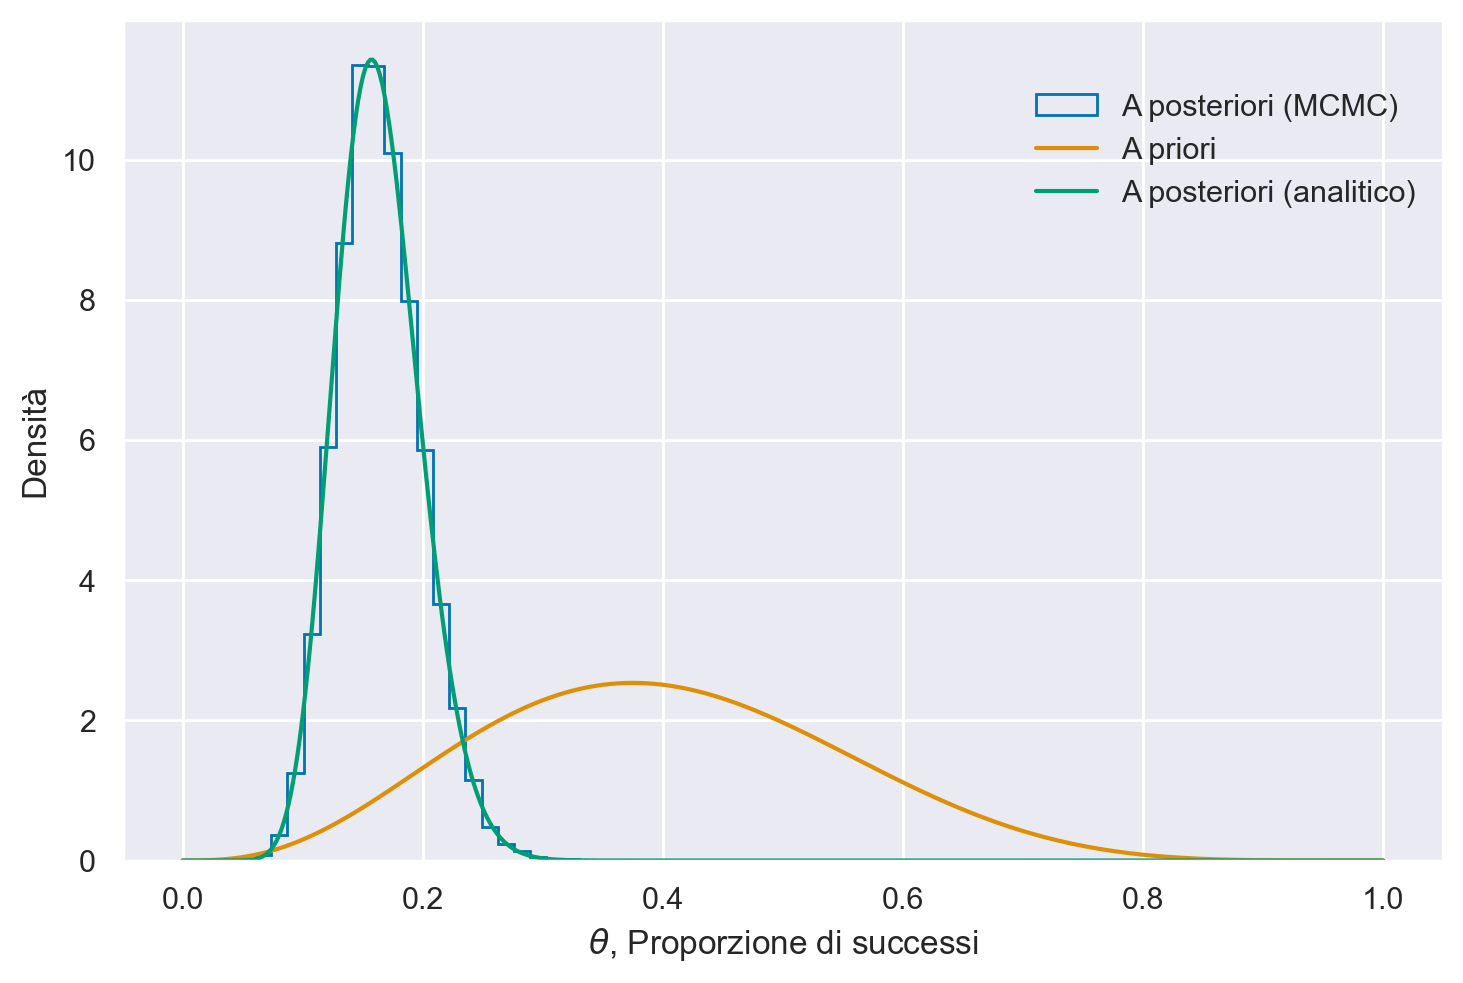

In [13]:
p_post = post["theta"]

# Posterior: Beta(alpha + y, beta + n - y)
alpha_post = alpha_prior + np.sum(data["y"])
beta_post = beta_prior + data["N"] - np.sum(data["y"])

plt.hist(
    p_post,
    bins=20,
    histtype="step",
    density=True,
    label="A posteriori (MCMC)",
    color="C0",
)

# Plot the analytic prior and posterior beta distributions
x = np.linspace(0, 1, 500)
plt.plot(
    x, stats.beta.pdf(x, alpha_prior, beta_prior), label="A priori", color="C1"
)
plt.plot(
    x,
    stats.beta.pdf(x, alpha_post, beta_post),
    label="A posteriori (analitico)",
    color="C2",
)

# Update the graph labels
plt.legend(title=" ", loc="best")
plt.xlabel("$\\theta$, Proporzione di successi")
plt.ylabel("Densità")

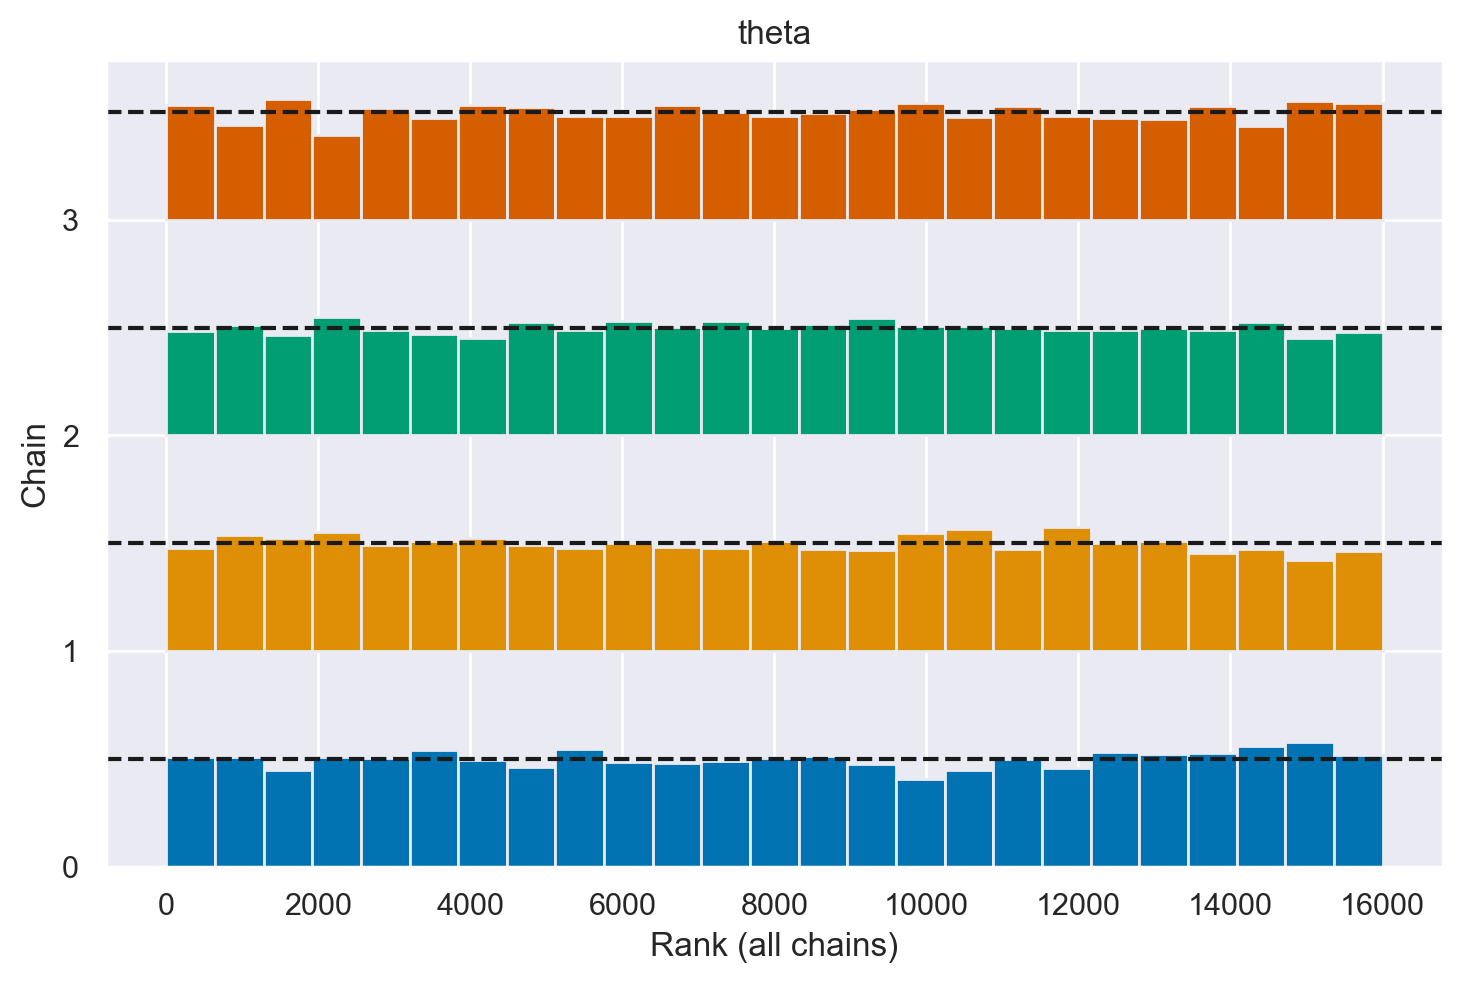

In [14]:
_ = az.plot_rank(fit, var_names="theta", kind="bars")

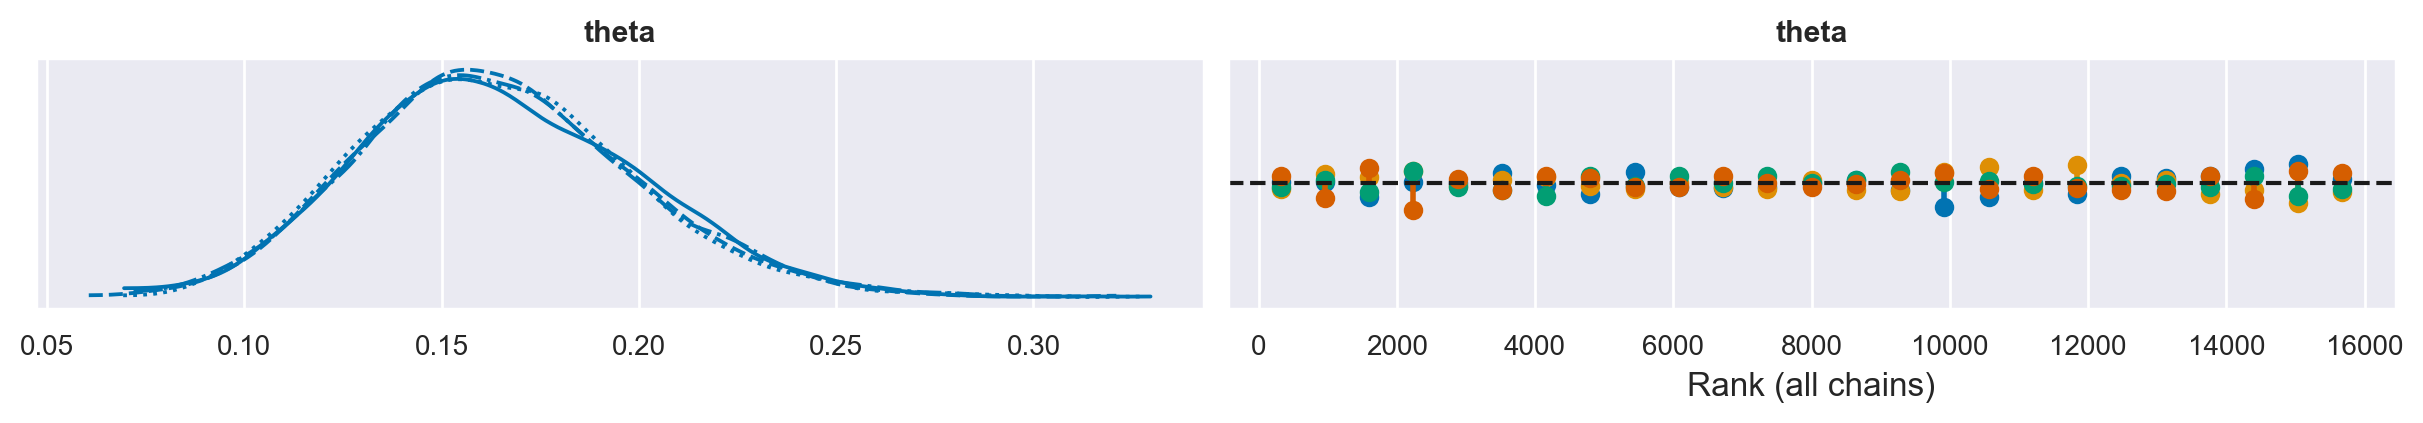

In [26]:
_ = az.plot_trace(fit, var_names=("theta"), kind="rank_vlines")

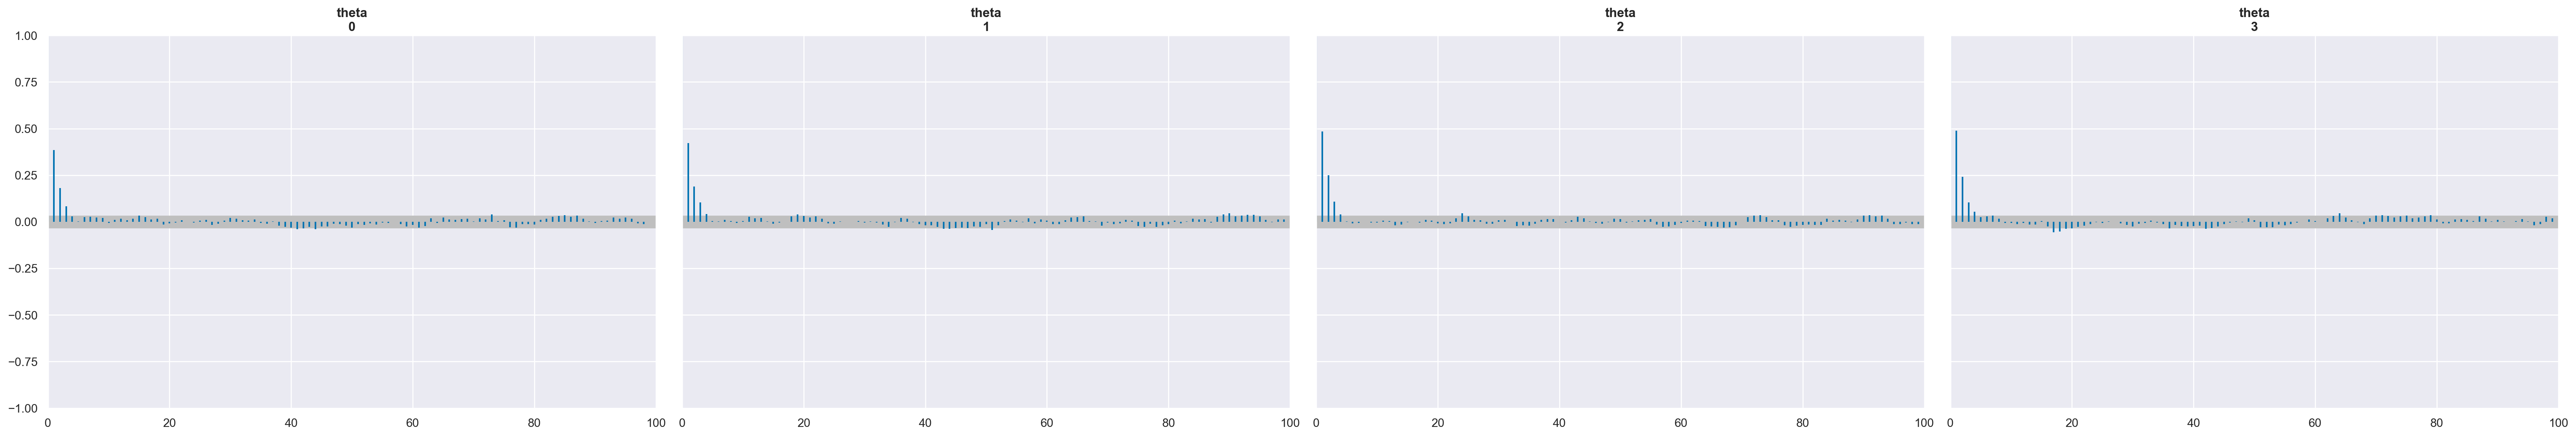

In [28]:
_ = az.plot_autocorr(fit, var_names=("theta"))

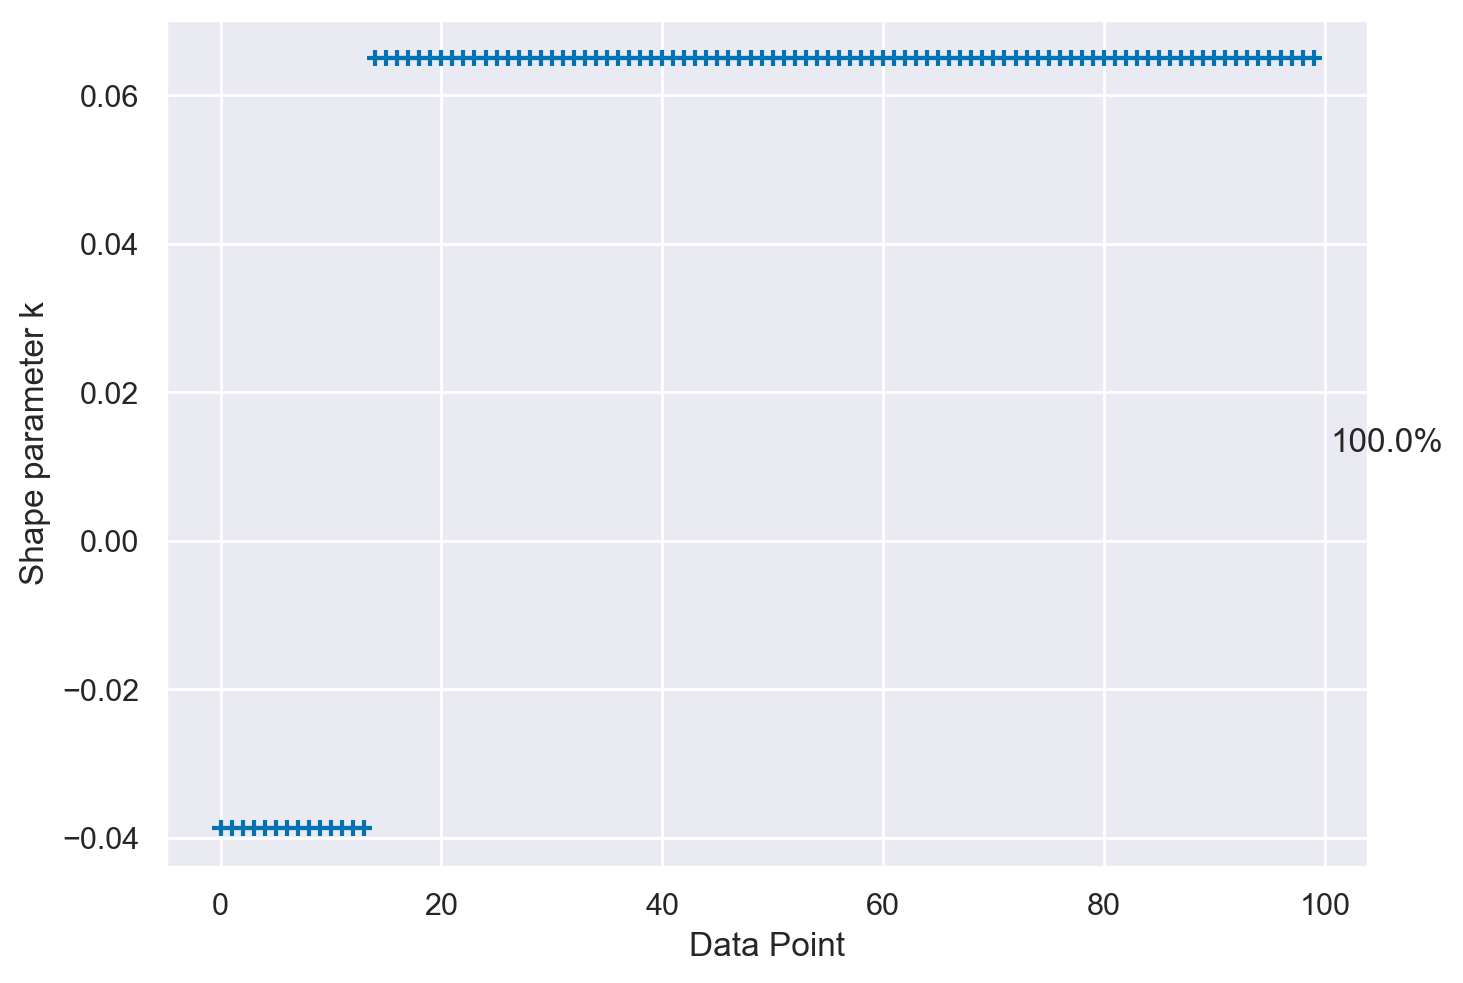

In [31]:
loo = az.loo(fit, pointwise=True)
_ = az.plot_khat(loo, show_bins=True)

Possiamo convertire l'oggetto `fit` in un oggetto di classe InferenceData nel modo seguente:

In [38]:
post = az.convert_to_inference_data(fit)
post

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

Per creare un PPC plot dobbiamo innanzitutto creare un oggetto InferenceData nel quale i dati sono strutturati come si aspetta Arviz:

In [51]:
idata = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive='y_rep',
    dtypes={"y_rep": int},
    observed_data={'y': data["y"]},
)

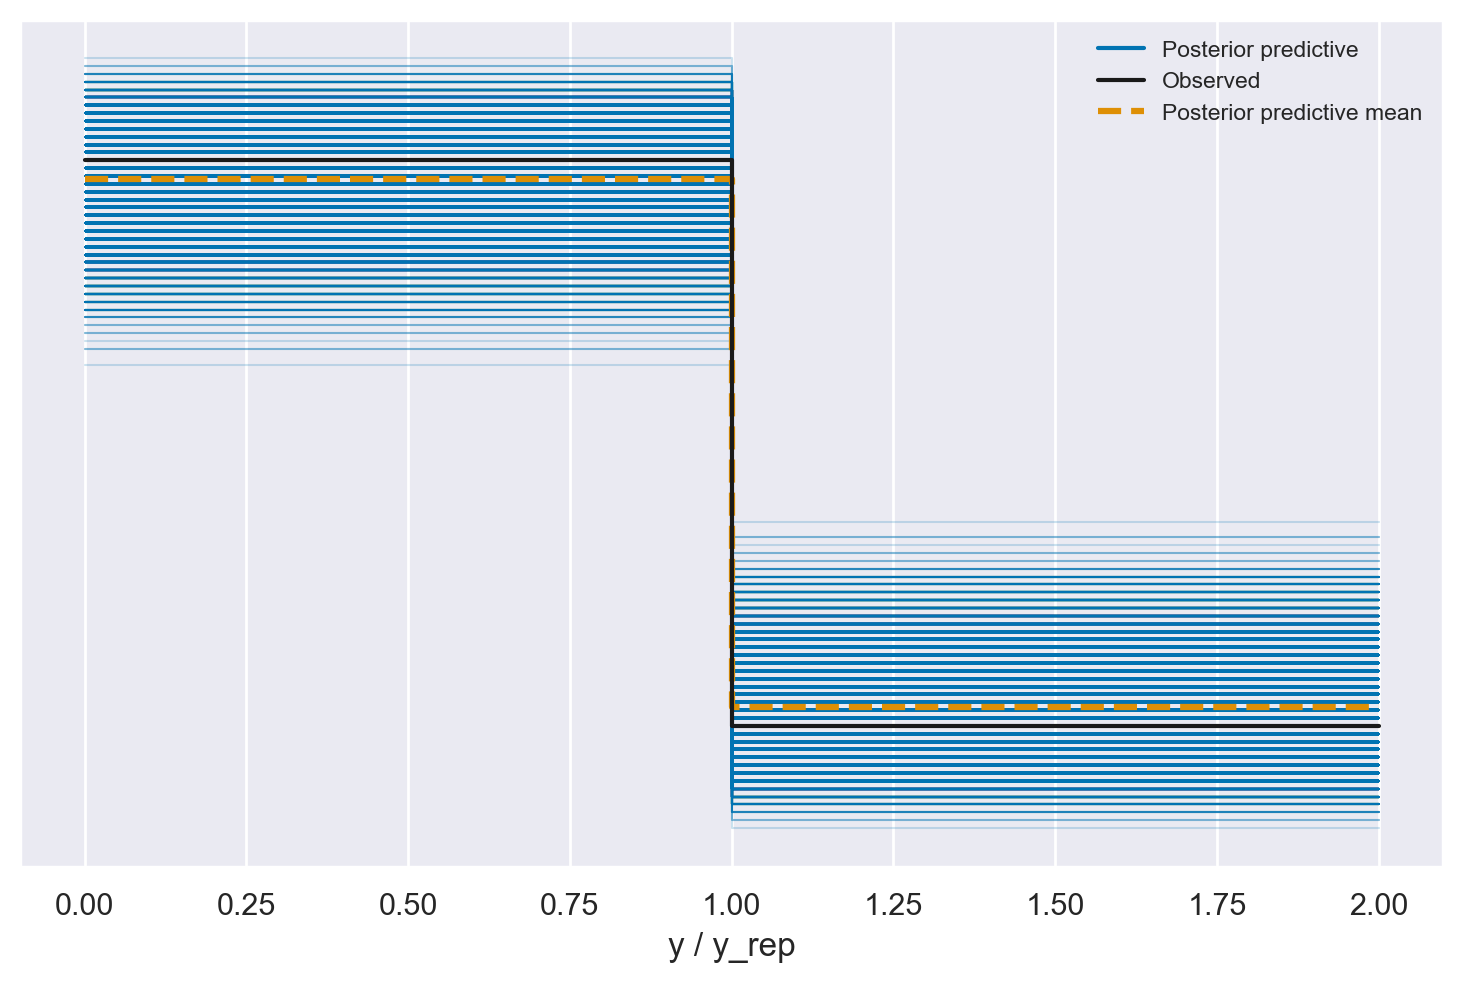

In [52]:
_ = az.plot_ppc(idata, data_pairs={'y': 'y_rep'})

## Watermark

In [15]:
%load_ext watermark
%watermark -n -u -v -iv -w -m -p cmdstanpy

Last updated: Sat Feb 24 2024

Python implementation: CPython
Python version       : 3.12.2
IPython version      : 8.22.1

cmdstanpy: 1.2.1

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

matplotlib: 3.8.3
numpy     : 1.26.4
arviz     : 0.17.0
pandas    : 2.2.1
seaborn   : 0.13.2
scipy     : 1.12.0

Watermark: 2.4.3

